# Credit Risk Analysis - Model Training
## Week 1: Building & Evaluating Predictive Models

### Objectives:
1. Load processed data from feature engineering
2. Handle class imbalance
3. Train multiple classification models
4. Perform hyperparameter tuning
5. Evaluate models with appropriate metrics
6. Select and save the best model

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

# Sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)

# Model Selection
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Processed Data

In [2]:
# Load train/test splits
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTarget distribution (train):")
print(pd.Series(y_train).value_counts(normalize=True) * 100)

Training set: (120000, 20)
Test set: (30000, 20)

Target distribution (train):
0    93.315833
1     6.684167
Name: proportion, dtype: float64


In [3]:
# Display feature names
print(f"Total features: {X_train.shape[1]}")
print(f"\nFeature list:")
for i, col in enumerate(X_train.columns, 1):
    print(f"{i:2d}. {col}")

Total features: 20

Feature list:
 1. RevolvingUtilizationOfUnsecuredLines
 2. age
 3. NumberOfTime30-59DaysPastDueNotWorse
 4. DebtRatio
 5. MonthlyIncome
 6. NumberOfOpenCreditLinesAndLoans
 7. NumberOfTimes90DaysLate
 8. NumberRealEstateLoansOrLines
 9. NumberOfTime60-89DaysPastDueNotWorse
10. NumberOfDependents
11. MonthlyIncome_Missing
12. NumberOfDependents_Missing
13. TotalDelinquencies
14. HasSevereDelinquency
15. UtilizationBucket
16. AgeGroup
17. IncomeToDebtRatio
18. UtilizationPerCreditLine
19. HasRealEstate
20. DebtToIncomeRatio


## 2. Class Imbalance Analysis

### Problem: Highly imbalanced dataset (~93% class 0, ~7% class 1)

### Solutions to try:
1. **Class weights**: Penalize misclassifying minority class more
2. **SMOTE**: Synthetic Minority Oversampling
3. **Hybrid**: Combination of SMOTE + Undersampling
4. **Evaluation metrics**: Focus on ROC-AUC, Precision-Recall instead of accuracy

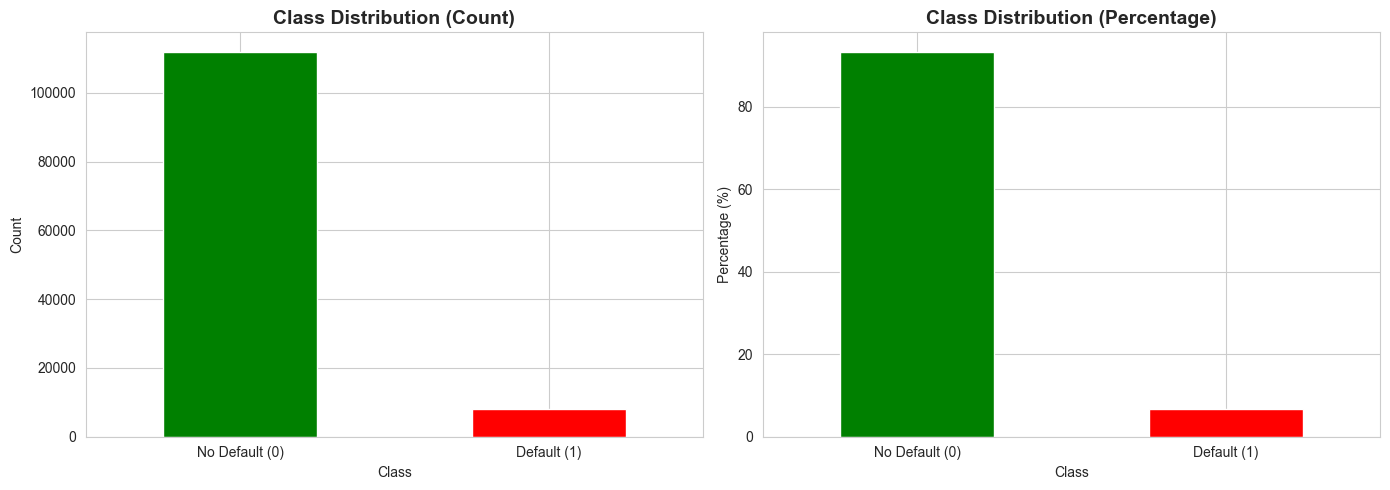


Imbalance Ratio: 13.96:1 (majority:minority)
This is a HIGHLY imbalanced dataset!


In [4]:
# Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)

# Percentage plot
(pd.Series(y_train).value_counts(normalize=True) * 100).plot(kind='bar', ax=axes[1], color=['green', 'red'])
axes[1].set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)

plt.tight_layout()
plt.show()

# Calculate imbalance ratio
class_counts = pd.Series(y_train).value_counts()
imbalance_ratio = class_counts[0] / class_counts[1]
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1 (majority:minority)")
print(f"This is a {'HIGHLY' if imbalance_ratio > 10 else 'MODERATELY'} imbalanced dataset!")

## 3. Define Evaluation Framework

### Important for Imbalanced Data:
- **Accuracy is misleading!** (predicting all 0s gives 93% accuracy)
- Focus on: **ROC-AUC**, **Precision-Recall AUC**, **F1-score**, **Recall**

In [5]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    """
    Comprehensive model evaluation for imbalanced classification
    """
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Probability predictions (for ROC-AUC)
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    results = {
        'Model': model_name,
        'Train_Accuracy': accuracy_score(y_train, y_train_pred),
        'Test_Accuracy': accuracy_score(y_test, y_test_pred),
        'Train_Precision': precision_score(y_train, y_train_pred),
        'Test_Precision': precision_score(y_test, y_test_pred),
        'Train_Recall': recall_score(y_train, y_train_pred),
        'Test_Recall': recall_score(y_test, y_test_pred),
        'Train_F1': f1_score(y_train, y_train_pred),
        'Test_F1': f1_score(y_test, y_test_pred),
        'Train_ROC_AUC': roc_auc_score(y_train, y_train_proba),
        'Test_ROC_AUC': roc_auc_score(y_test, y_test_proba),
        'Train_PR_AUC': average_precision_score(y_train, y_train_proba),
        'Test_PR_AUC': average_precision_score(y_test, y_test_proba)
    }
    
    return results, y_test_pred, y_test_proba

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    """
    Plot confusion matrix with percentages
    """
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    
    print("\nConfusion Matrix (Percentages):")
    print(f"True Negatives:  {cm_percent[0,0]:.1f}% ({cm[0,0]:,})")
    print(f"False Positives: {cm_percent[0,1]:.1f}% ({cm[0,1]:,})")
    print(f"False Negatives: {cm_percent[1,0]:.1f}% ({cm[1,0]:,})")
    print(f"True Positives:  {cm_percent[1,1]:.1f}% ({cm[1,1]:,})")

def plot_roc_curve(y_test, y_proba, model_name="Model"):
    """
    Plot ROC curve
    """
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title('ROC Curve', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_precision_recall_curve(y_test, y_proba, model_name="Model"):
    """
    Plot Precision-Recall curve (more informative for imbalanced data)
    """
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, linewidth=2, label=f'{model_name} (AP = {pr_auc:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

print("✓ Evaluation functions defined!")

✓ Evaluation functions defined!


## 4. Baseline Models (with Class Weights)

### Train multiple models with balanced class weights

In [6]:
# Initialize models with class weights
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        max_depth=10,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced',
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    )
}

print("Models initialized:")
for model_name in models.keys():
    print(f"  - {model_name}")

Models initialized:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - Gradient Boosting


In [7]:
# Train and evaluate all models
results_list = []

print("Training models...\n")
print("="*80)

for model_name, model in models.items():
    print(f"\n{model_name}")
    print("-" * len(model_name))
    
    # Train
    model.fit(X_train, y_train)
    print("✓ Training complete")
    
    # Evaluate
    results, y_pred, y_proba = evaluate_model(
        model, X_train, y_train, X_test, y_test, model_name
    )
    results_list.append(results)
    
    # Print key metrics
    print(f"Test ROC-AUC: {results['Test_ROC_AUC']:.4f}")
    print(f"Test PR-AUC:  {results['Test_PR_AUC']:.4f}")
    print(f"Test F1:      {results['Test_F1']:.4f}")
    print(f"Test Recall:  {results['Test_Recall']:.4f}")

print("\n" + "="*80)
print("✓ All models trained!")

Training models...


Logistic Regression
-------------------
✓ Training complete
Test ROC-AUC: 0.8622
Test PR-AUC:  0.4001
Test F1:      0.3452
Test Recall:  0.7541

Decision Tree
-------------
✓ Training complete
Test ROC-AUC: 0.8123
Test PR-AUC:  0.3492
Test F1:      0.3083
Test Recall:  0.7516

Random Forest
-------------
✓ Training complete
Test ROC-AUC: 0.8639
Test PR-AUC:  0.3835
Test F1:      0.3604
Test Recall:  0.7227

Gradient Boosting
-----------------
✓ Training complete
Test ROC-AUC: 0.8681
Test PR-AUC:  0.3966
Test F1:      0.2951
Test Recall:  0.1985

✓ All models trained!


In [8]:
# Compare models
results_df = pd.DataFrame(results_list)
results_df = results_df.round(4)

print("\n" + "="*80)
print("MODEL COMPARISON - TEST SET METRICS")
print("="*80)
print(results_df[['Model', 'Test_ROC_AUC', 'Test_PR_AUC', 'Test_F1', 'Test_Recall', 'Test_Precision']].to_string(index=False))


MODEL COMPARISON - TEST SET METRICS
              Model  Test_ROC_AUC  Test_PR_AUC  Test_F1  Test_Recall  Test_Precision
Logistic Regression        0.8622       0.4001   0.3452       0.7541          0.2238
      Decision Tree        0.8123       0.3492   0.3083       0.7516          0.1940
      Random Forest        0.8639       0.3835   0.3604       0.7227          0.2400
  Gradient Boosting        0.8681       0.3966   0.2951       0.1985          0.5751


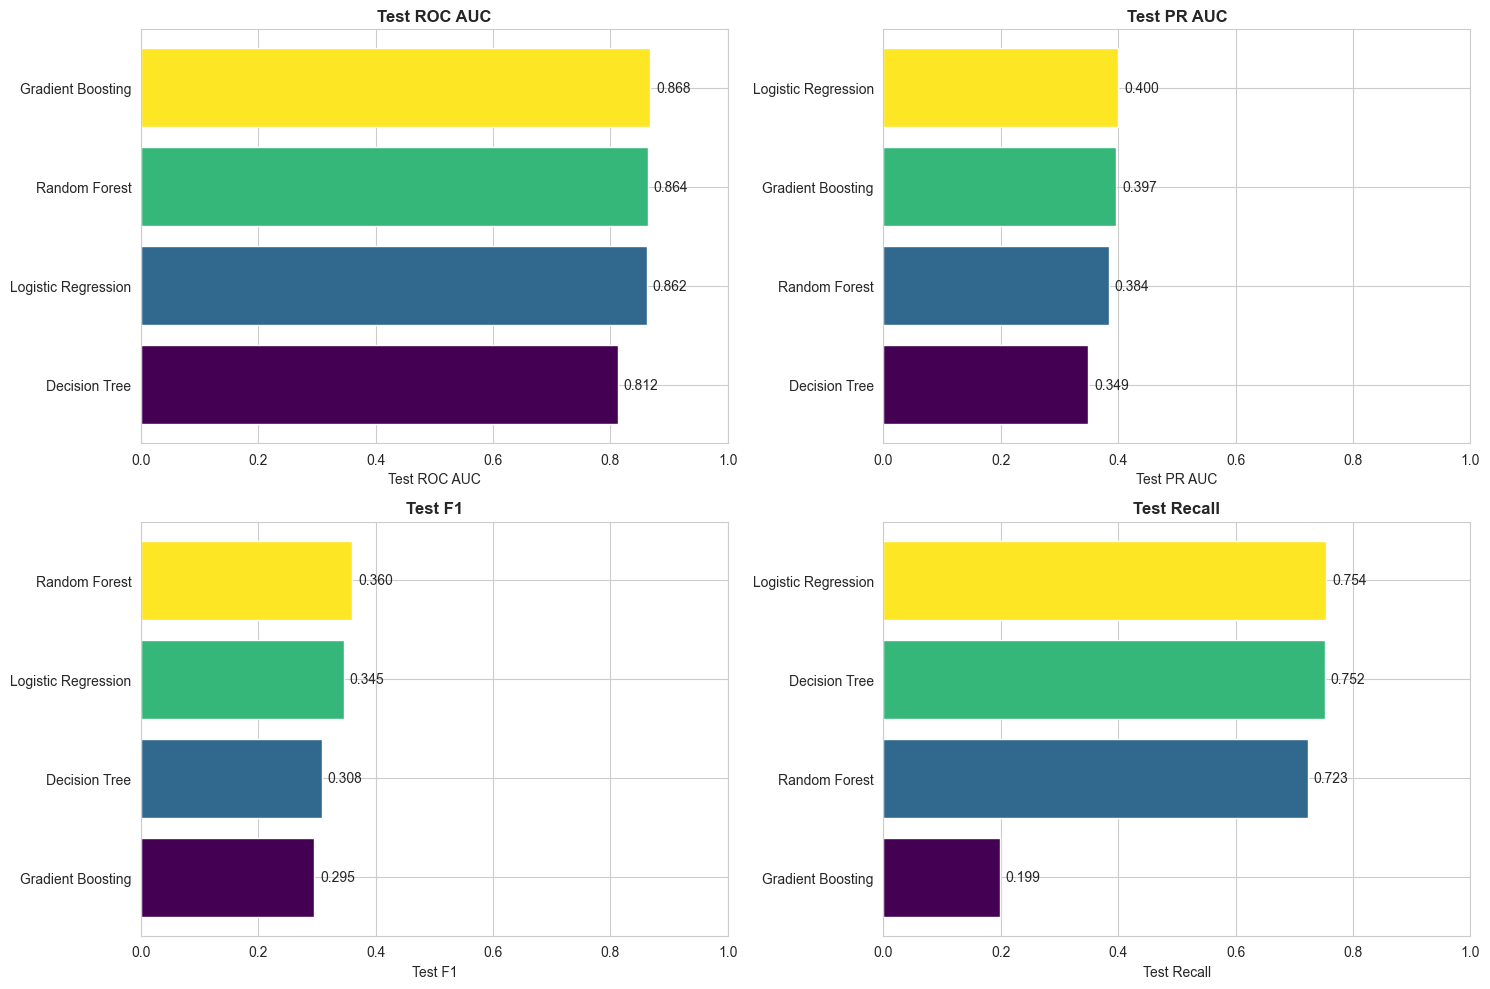

In [9]:
# Visualize model comparison
metrics_to_plot = ['Test_ROC_AUC', 'Test_PR_AUC', 'Test_F1', 'Test_Recall']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    data = results_df[['Model', metric]].sort_values(metric, ascending=True)
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(data)))
    ax.barh(data['Model'], data[metric], color=colors)
    ax.set_xlabel(metric.replace('_', ' '))
    ax.set_title(metric.replace('_', ' '), fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    
    # Add values on bars
    for i, v in enumerate(data[metric]):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

## 5. Select Best Model & Detailed Evaluation

In [10]:
# Select best model based on ROC-AUC
best_model_idx = results_df['Test_ROC_AUC'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_model = models[best_model_name]

print("="*80)
print(f"BEST MODEL: {best_model_name}")
print("="*80)
print(f"Test ROC-AUC: {results_df.loc[best_model_idx, 'Test_ROC_AUC']:.4f}")
print(f"Test PR-AUC:  {results_df.loc[best_model_idx, 'Test_PR_AUC']:.4f}")
print(f"Test F1:      {results_df.loc[best_model_idx, 'Test_F1']:.4f}")

BEST MODEL: Gradient Boosting
Test ROC-AUC: 0.8681
Test PR-AUC:  0.3966
Test F1:      0.2951


In [11]:
# Detailed evaluation of best model
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['No Default', 'Default']))


Classification Report:
              precision    recall  f1-score   support

  No Default       0.95      0.99      0.97     27995
     Default       0.58      0.20      0.30      2005

    accuracy                           0.94     30000
   macro avg       0.76      0.59      0.63     30000
weighted avg       0.92      0.94      0.92     30000



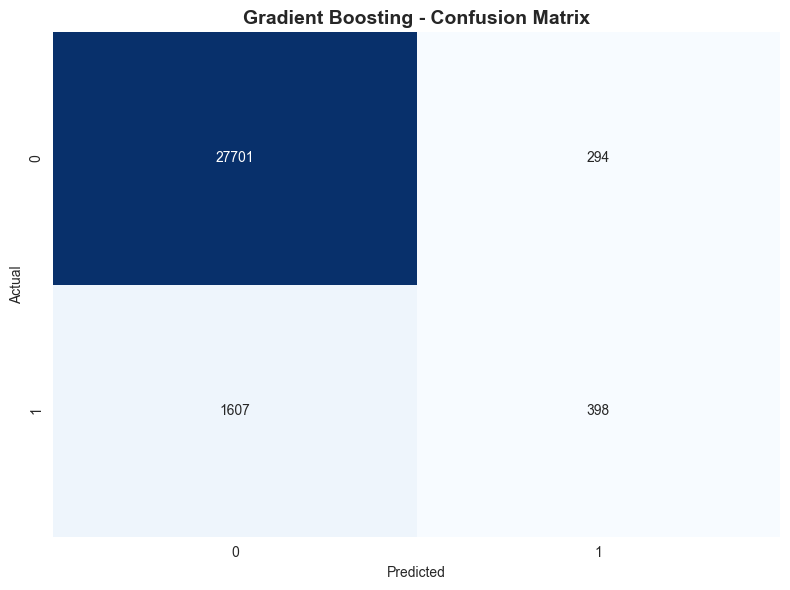


Confusion Matrix (Percentages):
True Negatives:  98.9% (27,701)
False Positives: 1.1% (294)
False Negatives: 80.1% (1,607)
True Positives:  19.9% (398)


In [12]:
# Confusion Matrix
plot_confusion_matrix(y_test, y_test_pred, title=f"{best_model_name} - Confusion Matrix")

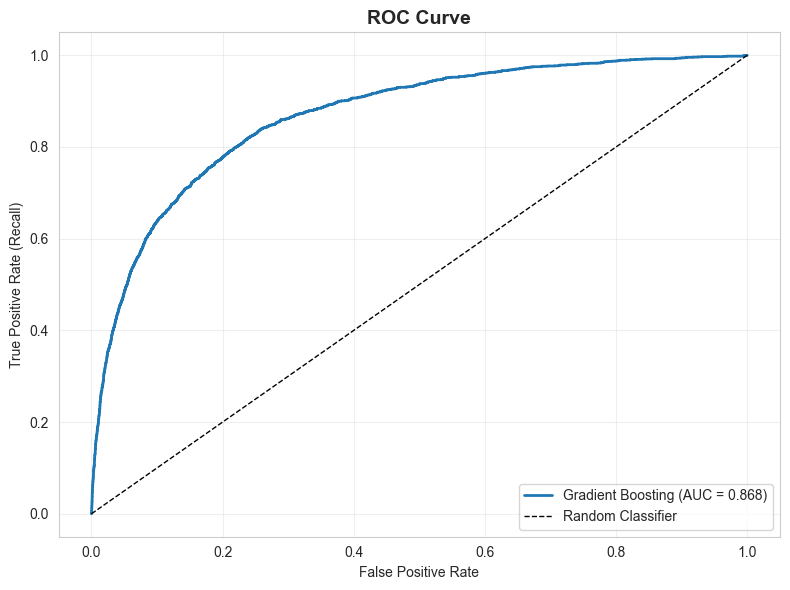

In [13]:
# ROC Curve
plot_roc_curve(y_test, y_test_proba, model_name=best_model_name)

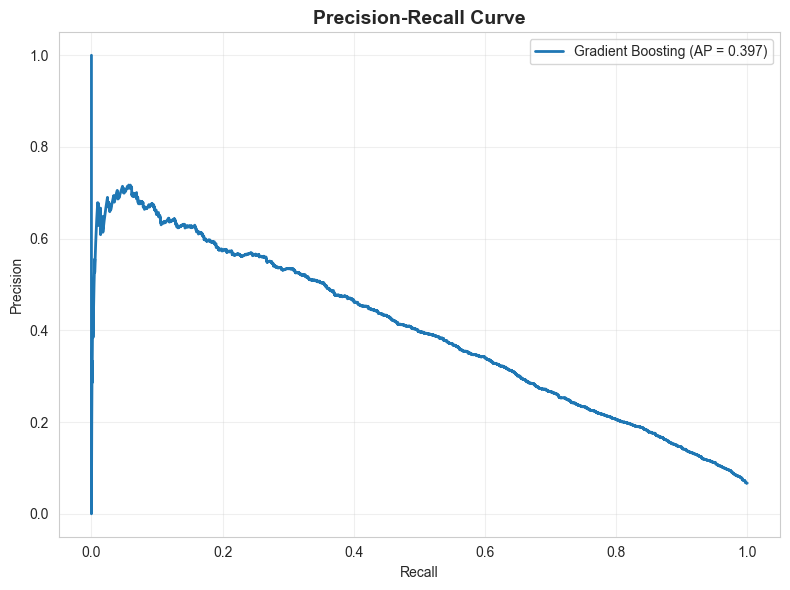

In [14]:
# Precision-Recall Curve (more important for imbalanced data)
plot_precision_recall_curve(y_test, y_test_proba, model_name=best_model_name)

## 6. Feature Importance Analysis

Top 15 Most Important Features:
                             Feature  Importance
                  TotalDelinquencies    0.565108
RevolvingUtilizationOfUnsecuredLines    0.147313
             NumberOfTimes90DaysLate    0.057174
                                 age    0.030029
                HasSevereDelinquency    0.029470
            UtilizationPerCreditLine    0.027859
                           DebtRatio    0.023011
                   IncomeToDebtRatio    0.020558
                       MonthlyIncome    0.020192
                   DebtToIncomeRatio    0.018711
NumberOfTime30-59DaysPastDueNotWorse    0.015130
        NumberRealEstateLoansOrLines    0.012458
NumberOfTime60-89DaysPastDueNotWorse    0.011779
     NumberOfOpenCreditLinesAndLoans    0.010807
                  NumberOfDependents    0.007777


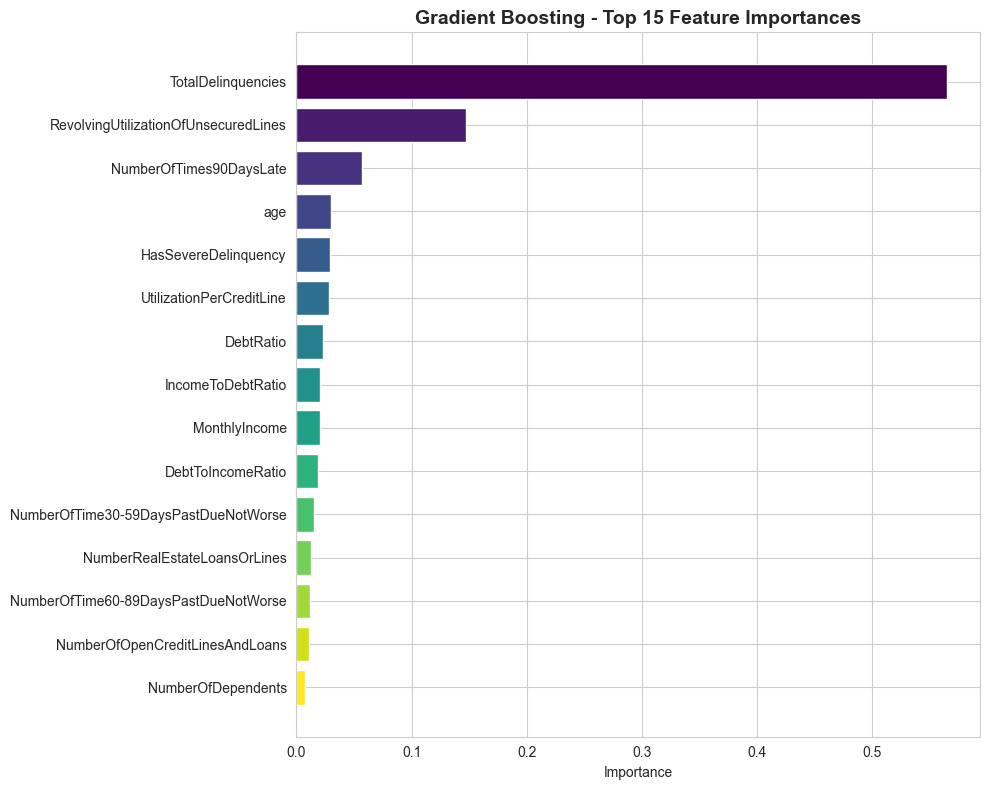

In [15]:
# Feature importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("Top 15 Most Important Features:")
    print(feature_importance.head(15).to_string(index=False))
    
    # Plot
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(15)
    colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
    plt.barh(range(len(top_features)), top_features['Importance'], color=colors)
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance')
    plt.title(f'{best_model_name} - Top 15 Feature Importances', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
elif hasattr(best_model, 'coef_'):
    # For linear models (Logistic Regression)
    coefficients = pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': best_model.coef_[0]
    }).sort_values('Coefficient', key=abs, ascending=False)
    
    print("Top 15 Most Important Features (by coefficient magnitude):")
    print(coefficients.head(15).to_string(index=False))
    
    # Plot
    plt.figure(figsize=(10, 8))
    top_features = coefficients.head(15)
    colors = ['red' if x < 0 else 'green' for x in top_features['Coefficient']]
    plt.barh(range(len(top_features)), top_features['Coefficient'], color=colors)
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Coefficient (impact on default probability)')
    plt.title(f'{best_model_name} - Top 15 Feature Coefficients', fontsize=14, fontweight='bold')
    plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance not available for this model.")

## 7. Hyperparameter Tuning (Optional - Can be time-consuming)

### Use GridSearchCV to find optimal hyperparameters for the best model

In [16]:
# Example: Tune Random Forest (adjust based on your best model)
# UNCOMMENT AND RUN THIS CELL IF YOU WANT TO PERFORM HYPERPARAMETER TUNING

"""
if best_model_name == 'Random Forest':
    print("Starting hyperparameter tuning for Random Forest...")
    print("This may take several minutes...\n")
    
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 15, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'class_weight': ['balanced']
    }
    
    rf_tuned = GridSearchCV(
        RandomForestClassifier(random_state=42, n_jobs=-1),
        param_grid,
        cv=3,
        scoring='roc_auc',
        verbose=2,
        n_jobs=-1
    )
    
    rf_tuned.fit(X_train, y_train)
    
    print(f"\nBest parameters: {rf_tuned.best_params_}")
    print(f"Best CV ROC-AUC: {rf_tuned.best_score_:.4f}")
    
    # Update best model
    best_model = rf_tuned.best_estimator_
    
    # Re-evaluate
    y_test_pred = best_model.predict(X_test)
    y_test_proba = best_model.predict_proba(X_test)[:, 1]
    
    print(f"\nTuned model Test ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}")
    print(f"Tuned model Test PR-AUC: {average_precision_score(y_test, y_test_proba):.4f}")
"""

print("Note: Hyperparameter tuning cell is commented out.")
print("Uncomment the code above if you want to perform tuning (may take time).")

Note: Hyperparameter tuning cell is commented out.
Uncomment the code above if you want to perform tuning (may take time).


## 8. Cross-Validation for Model Stability

In [17]:
# Perform 5-fold stratified cross-validation on best model
print(f"Performing 5-fold cross-validation on {best_model_name}...\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ROC-AUC scores
cv_roc_scores = cross_val_score(
    best_model, X_train, y_train,
    cv=cv, scoring='roc_auc', n_jobs=-1
)

print("Cross-Validation ROC-AUC Scores:")
for i, score in enumerate(cv_roc_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nMean ROC-AUC: {cv_roc_scores.mean():.4f} (+/- {cv_roc_scores.std() * 2:.4f})")
print(f"Min ROC-AUC:  {cv_roc_scores.min():.4f}")
print(f"Max ROC-AUC:  {cv_roc_scores.max():.4f}")

Performing 5-fold cross-validation on Gradient Boosting...

Cross-Validation ROC-AUC Scores:
  Fold 1: 0.8671
  Fold 2: 0.8614
  Fold 3: 0.8610
  Fold 4: 0.8624
  Fold 5: 0.8662

Mean ROC-AUC: 0.8636 (+/- 0.0051)
Min ROC-AUC:  0.8610
Max ROC-AUC:  0.8671


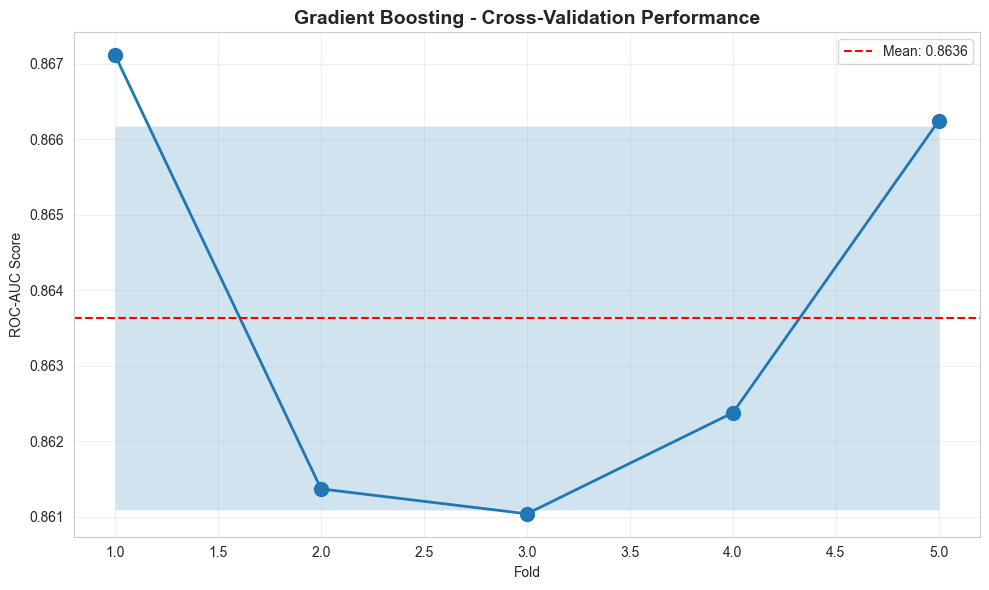

In [18]:
# Visualize CV scores
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), cv_roc_scores, 'o-', linewidth=2, markersize=10)
plt.axhline(y=cv_roc_scores.mean(), color='r', linestyle='--', label=f'Mean: {cv_roc_scores.mean():.4f}')
plt.fill_between(
    range(1, 6),
    cv_roc_scores.mean() - cv_roc_scores.std(),
    cv_roc_scores.mean() + cv_roc_scores.std(),
    alpha=0.2
)
plt.xlabel('Fold')
plt.ylabel('ROC-AUC Score')
plt.title(f'{best_model_name} - Cross-Validation Performance', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Save Best Model

In [19]:
# Save the best model
import os
os.makedirs('../models', exist_ok=True)

model_path = '../models/best_model.pkl'
joblib.dump(best_model, model_path)

print(f"✓ Best model saved to: {model_path}")
print(f"  Model type: {best_model_name}")

✓ Best model saved to: ../models/best_model.pkl
  Model type: Gradient Boosting


In [20]:
# Save model performance metrics
metrics_path = '../models/model_performance.csv'
results_df.to_csv(metrics_path, index=False)

print(f"✓ Model performance metrics saved to: {metrics_path}")

✓ Model performance metrics saved to: ../models/model_performance.csv


In [21]:
# Save feature importance (if available)
if hasattr(best_model, 'feature_importances_'):
    feature_importance.to_csv('../models/feature_importance.csv', index=False)
    print("✓ Feature importance saved to: ../models/feature_importance.csv")
elif hasattr(best_model, 'coef_'):
    coefficients.to_csv('../models/feature_coefficients.csv', index=False)
    print("✓ Feature coefficients saved to: ../models/feature_coefficients.csv")

✓ Feature importance saved to: ../models/feature_importance.csv


## 10. Final Summary & Next Steps

In [22]:
print("\n" + "="*80)
print("MODEL TRAINING COMPLETE - FINAL SUMMARY")
print("="*80)

print(f"\n1. Models Trained: {len(models)}")
print(f"   - {', '.join(models.keys())}")

print(f"\n2. Best Model: {best_model_name}")
print(f"   - Test ROC-AUC: {results_df.loc[best_model_idx, 'Test_ROC_AUC']:.4f}")
print(f"   - Test PR-AUC:  {results_df.loc[best_model_idx, 'Test_PR_AUC']:.4f}")
print(f"   - Test F1:      {results_df.loc[best_model_idx, 'Test_F1']:.4f}")
print(f"   - Test Recall:  {results_df.loc[best_model_idx, 'Test_Recall']:.4f}")

print(f"\n3. Cross-Validation:")
print(f"   - Mean ROC-AUC: {cv_roc_scores.mean():.4f} (+/- {cv_roc_scores.std() * 2:.4f})")

print(f"\n4. Saved Artifacts:")
print(f"   - Best model: ../models/best_model.pkl")
print(f"   - Performance metrics: ../models/model_performance.csv")
if hasattr(best_model, 'feature_importances_') or hasattr(best_model, 'coef_'):
    print(f"   - Feature importance/coefficients: ../models/feature_*.csv")

print("\n" + "="*80)
print("✓ READY FOR MODEL DEPLOYMENT & MONITORING!")
print("Next Steps:")
print("  - Create prediction pipeline")
print("  - Deploy model to production")
print("  - Set up monitoring & retraining")
print("="*80)


MODEL TRAINING COMPLETE - FINAL SUMMARY

1. Models Trained: 4
   - Logistic Regression, Decision Tree, Random Forest, Gradient Boosting

2. Best Model: Gradient Boosting
   - Test ROC-AUC: 0.8681
   - Test PR-AUC:  0.3966
   - Test F1:      0.2951
   - Test Recall:  0.1985

3. Cross-Validation:
   - Mean ROC-AUC: 0.8636 (+/- 0.0051)

4. Saved Artifacts:
   - Best model: ../models/best_model.pkl
   - Performance metrics: ../models/model_performance.csv
   - Feature importance/coefficients: ../models/feature_*.csv

✓ READY FOR MODEL DEPLOYMENT & MONITORING!
Next Steps:
  - Create prediction pipeline
  - Deploy model to production
  - Set up monitoring & retraining
